## Exploración geométrica de estrategias de inicialización mediante PCA

Este notebook explora diferentes formas de identificar observaciones extremas en una proyección bidimensional obtenida mediante PCA. El análisis utiliza exclusivamente una muestra del conjunto de entrenamiento y tiene un propósito exploratorio.

Los resultados permiten estudiar geométricamente posibles candidatos para inicializar el análisis de arquetipos, pero no determinan por sí solos la inicialización final. La comparación experimental de las estrategias de inicialización se realiza posteriormente utilizando el conjunto de validación.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.decomposition import PCA

%matplotlib inline

In [ ]:
def encontrar_raiz_proyecto():
    """Buscar la raíz del proyecto desde el directorio actual."""

    ruta_actual = Path.cwd().resolve()

    for ruta_candidata in (
        ruta_actual,
        *ruta_actual.parents,
    ):
        tiene_src = (
            ruta_candidata
            / "src"
        ).is_dir()

        tiene_notebooks = (
            ruta_candidata
            / "notebooks"
        ).is_dir()

        if tiene_src and tiene_notebooks:
            return ruta_candidata

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto."
    )


RUTA_PROYECTO = encontrar_raiz_proyecto()


# Permitir la importación de los módulos del proyecto
if str(RUTA_PROYECTO) not in sys.path:
    sys.path.insert(
        0,
        str(RUTA_PROYECTO),
    )


from src.loaders import cargar_dataset
from src.normalizacion import aplicar_normalizacion


# Cargar únicamente la población principal ya particionada
datos = cargar_dataset(
    "interpolacion_50"
)


X_train = datos["train"]["X"]
metadata_train = datos["train"]["metadata"]


# Seleccionar una muestra reproducible del conjunto de entrenamiento
n_muestra = min(
    1000,
    X_train.shape[0],
)

generador = np.random.default_rng(
    seed=42,
)

indices_muestra = generador.choice(
    X_train.shape[0],
    size=n_muestra,
    replace=False,
)


X_sample_original = X_train[
    indices_muestra
]

metadata_sample = (
    metadata_train
    .iloc[indices_muestra]
    .reset_index(drop=True)
)


# Aplicar la normalización utilizada en la comparación
# experimental de inicializaciones
X_sample = aplicar_normalizacion(
    X_sample_original,
    metodo="minmax",
)


print(
    "Raíz del proyecto:",
    RUTA_PROYECTO,
)

print(
    "Curvas disponibles en entrenamiento:",
    X_train.shape,
)

print(
    "Muestra utilizada en la exploración:",
    X_sample.shape,
)

print(
    "Particiones presentes en la muestra:",
    metadata_sample["particion"].unique(),
)

Raíz del proyecto: C:\Users\adanm\Code\tesis
Curvas disponibles en entrenamiento: (61466, 50)
Muestra utilizada en la exploración: (1000, 50)
Particiones presentes en la muestra: <ArrowStringArray>
['train']
Length: 1, dtype: str


In [4]:
# Proyectar la muestra normalizada en dos componentes principales
pca = PCA(
    n_components=2,
)

X_pca = pca.fit_transform(
    X_sample
)


# Calcular el centroide de la muestra en el espacio bidimensional
centroide = X_pca.mean(
    axis=0
)


# Obtener la proporción de varianza explicada
varianza_explicada = (
    pca.explained_variance_ratio_
)


print(
    "Dimensiones del espacio PCA:",
    X_pca.shape,
)

print(
    "Varianza explicada por PC1: "
    f"{varianza_explicada[0] * 100:.2f}%"
)

print(
    "Varianza explicada por PC2: "
    f"{varianza_explicada[1] * 100:.2f}%"
)

print(
    "Varianza total explicada en dos dimensiones: "
    f"{varianza_explicada.sum() * 100:.2f}%"
)

print(
    "Centroide en el espacio PCA:",
    centroide,
)

Dimensiones del espacio PCA: (1000, 2)
Varianza explicada por PC1: 41.56%
Varianza explicada por PC2: 14.58%
Varianza total explicada en dos dimensiones: 56.14%
Centroide en el espacio PCA: [-8.21565038e-18 -7.94919686e-17]


In [5]:
# Calcular la distancia euclidiana de cada curva
# al centroide de la muestra en el espacio PCA
distancias_centroide = np.linalg.norm(
    X_pca - centroide,
    axis=1,
)


# Seleccionar las diez curvas más alejadas
indices_enfoque1 = np.argsort(
    distancias_centroide
)[-10:]


print(
    "Curvas seleccionadas por distancia al centroide:",
    len(indices_enfoque1),
)

print(
    "Índices dentro de la muestra:",
    indices_enfoque1,
)


Curvas seleccionadas por distancia al centroide: 10
Índices dentro de la muestra: [397 200 708  12 961 902 134 265 385  53]


In [6]:
# Identificar los extremos de los dos componentes principales
idx_min_pc1 = np.argmin(
    X_pca[:, 0]
)

idx_max_pc1 = np.argmax(
    X_pca[:, 0]
)

idx_min_pc2 = np.argmin(
    X_pca[:, 1]
)

idx_max_pc2 = np.argmax(
    X_pca[:, 1]
)


# Eliminar posibles índices repetidos y mantener
# un orden determinista
indices_enfoque2 = np.unique(
    [
        idx_min_pc1,
        idx_max_pc1,
        idx_min_pc2,
        idx_max_pc2,
    ]
)


print(
    "Extremo inferior de PC1:",
    idx_min_pc1,
)

print(
    "Extremo superior de PC1:",
    idx_max_pc1,
)

print(
    "Extremo inferior de PC2:",
    idx_min_pc2,
)

print(
    "Extremo superior de PC2:",
    idx_max_pc2,
)

print(
    "Curvas extremas únicas:",
    len(indices_enfoque2),
)

Extremo inferior de PC1: 385
Extremo superior de PC1: 79
Extremo inferior de PC2: 530
Extremo superior de PC2: 749
Curvas extremas únicas: 4


In [7]:
# Calcular la envolvente convexa de la muestra
# en el espacio bidimensional obtenido mediante PCA
envolvente = ConvexHull(
    X_pca
)


# Obtener los índices de las curvas que forman
# los vértices de la envolvente
indices_enfoque3 = envolvente.vertices


print(
    "Curvas ubicadas en los vértices "
    "de la envolvente convexa:",
    len(indices_enfoque3),
)

print(
    "Índices dentro de la muestra:",
    indices_enfoque3,
)

Curvas ubicadas en los vértices de la envolvente convexa: 17
Índices dentro de la muestra: [385 902 308 506 921 140 530 979 323 879  79 592  16 898 749 837  53]


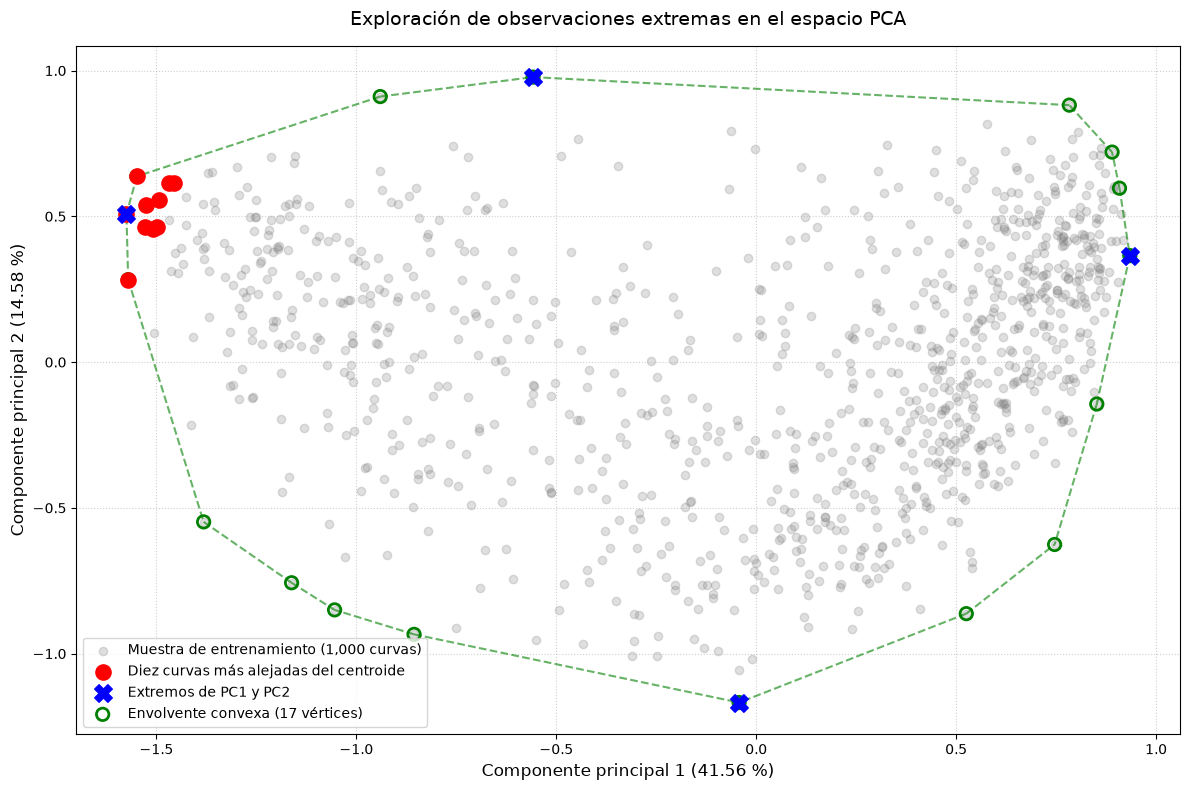

In [9]:
# Crear la figura
fig, ax = plt.subplots(
    figsize=(12, 8),
    dpi=100,
)


# Dibujar las curvas de la muestra en el espacio PCA
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.25,
    color="gray",
    label=f"Muestra de entrenamiento ({len(X_pca):,} curvas)",
)


# Dibujar las aristas de la envolvente convexa
for arista in envolvente.simplices:
    ax.plot(
        X_pca[arista, 0],
        X_pca[arista, 1],
        color="green",
        linestyle="--",
        alpha=0.6,
        linewidth=1.5,
    )


# Resaltar las curvas más alejadas del centroide
ax.scatter(
    X_pca[indices_enfoque1, 0],
    X_pca[indices_enfoque1, 1],
    color="red",
    s=120,
    zorder=3,
    label="Diez curvas más alejadas del centroide",
)


# Resaltar los extremos de los ejes principales
ax.scatter(
    X_pca[indices_enfoque2, 0],
    X_pca[indices_enfoque2, 1],
    color="blue",
    s=160,
    marker="X",
    zorder=4,
    label="Extremos de PC1 y PC2",
)


# Resaltar los vértices de la envolvente convexa
ax.scatter(
    X_pca[indices_enfoque3, 0],
    X_pca[indices_enfoque3, 1],
    s=80,
    facecolors="none",
    edgecolors="green",
    linewidth=2,
    zorder=2,
    label=(
        "Envolvente convexa "
        f"({len(indices_enfoque3)} vértices)"
    ),
)


ax.set_title(
    "Exploración de observaciones extremas en el espacio PCA",
    fontsize=14,
    pad=15,
)

ax.set_xlabel(
    "Componente principal 1 "
    f"({varianza_explicada[0] * 100:.2f} %)",
    fontsize=12,
)

ax.set_ylabel(
    "Componente principal 2 "
    f"({varianza_explicada[1] * 100:.2f} %)",
    fontsize=12,
)

ax.legend(
    loc="best",
    fontsize=10,
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.6,
)

plt.tight_layout()
plt.show()

## Interpretación de la exploración geométrica

Los dos primeros componentes principales explican en conjunto el \(56.14\,\%\) de la variabilidad presente en la muestra. Por tanto, la proyección permite examinar parte de la estructura geométrica de las curvas, pero no representa completamente el espacio original de 50 dimensiones.

La selección basada en la distancia al centroide identifica diez curvas alejadas de la región central, aunque no garantiza que estas se distribuyan en distintas direcciones. La selección de los valores mínimos y máximos de los dos componentes produce cuatro candidatos y representa únicamente los extremos de los ejes observados.

La envolvente convexa identifica 17 curvas situadas en la frontera de la muestra proyectada. Este conjunto ofrece una cobertura más amplia de las distintas direcciones visibles en el espacio bidimensional y puede utilizarse como un conjunto de candidatos para una selección posterior mediante *Furthest Sum*.

Estos resultados no demuestran que las curvas seleccionadas sean arquetipos ni que esta estrategia constituya la inicialización óptima. La envolvente se calculó sobre una muestra de 1.000 curvas de entrenamiento y en una proyección que conserva el \(56.14\,\%\) de la variabilidad. Por ello, este análisis se considera una exploración geométrica que justifica incluir la estrategia `pca_convex_hull_furthest_sum` en la comparación experimental de inicializaciones. La selección final se realiza posteriormente utilizando las métricas obtenidas en validación.
